In [1]:
import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from matplotlib import pyplot as plt
!pip install jiwer # install jiwer if you haven't already
import jiwer # for calculating CER

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load training and validation data

In [3]:
train_csv_path = Path("/content/drive/MyDrive/dl_project/train.csv")# Adjust path to point to the correct location
val_csv_path = Path("/content/drive/MyDrive/dl_project/val.csv")

class ImageDataset(Dataset):
    def __init__(self, csv_file, transform=None, root_dir=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.root_dir = Path(root_dir) if root_dir else None

    def __len__(self):
        return len(self.data)

    def _resolve_path(self, path):
        p = Path(path)
        if self.root_dir:
            p = self.root_dir / p
        return p

    def __getitem__(self, idx):
        img_rel_path = self.data.iloc[idx]['image_path']
        label = self.data.iloc[idx]['label']
        image_path = self._resolve_path(img_rel_path) # Corrected path resolution
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

### Plot sample images

In [4]:
train_ds = ImageDataset("/content/drive/MyDrive/DeepLearning project/dl_project/train.csv", transform=transforms.Compose([
    transforms.Resize((64, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]), root_dir="/content/drive/MyDrive/DeepLearning project/dl_project/")

val_ds = ImageDataset("/content/drive/MyDrive/DeepLearning project/dl_project/val.csv", transform=transforms.Compose([
    transforms.Resize((64, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406],   std=[0.229, 0.224, 0.225]),
]), root_dir="/content/drive/MyDrive/DeepLearning project/dl_project/")

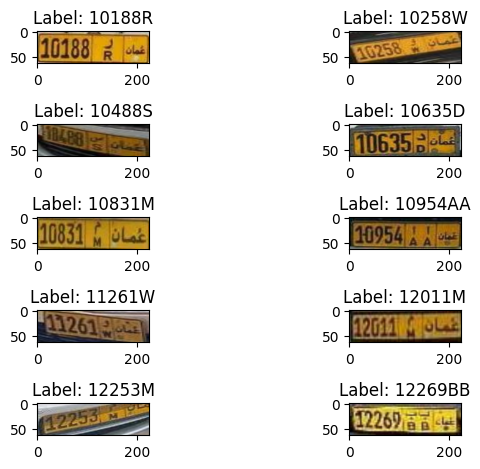

In [5]:
i = 0
figure, ax = plt.subplots(5,2)
for img, label in train_ds:
    ax[i//2, i%2].imshow(img.permute(1, 2, 0)) # note PIL image has shape (C, H, W) but (H, W, C) is needed for plt.imshow
    ax[i//2, i%2].set_title(f"Label: {label}")

    i += 1
    if i >= 10:
        break
plt.tight_layout()
plt.show()

## Build label vocabulary (y targets encoding)

In [6]:
def build_vocab(labels):
    chars = sorted({c for s in labels for c in str(s)})
    vocab = {c: i + 1 for i, c in enumerate(chars)}  # 0 is PAD
    inv_vocab = {i: c for c, i in vocab.items()}
    return vocab, inv_vocab

train_df = pd.read_csv("/content/drive/MyDrive/DeepLearning project/dl_project/train.csv")
vocab, inv_vocab = build_vocab(train_df["label"].tolist()) # get all unique characters from the labels and build a vocab
max_len = int(train_df["label"].astype(str).map(len).max())
num_classes = len(vocab) + 1

In [7]:
vocab,inv_vocab, max_len, num_classes

({'0': 1,
  '1': 2,
  '2': 3,
  '3': 4,
  '4': 5,
  '5': 6,
  '6': 7,
  '7': 8,
  '8': 9,
  '9': 10,
  'A': 11,
  'B': 12,
  'D': 13,
  'H': 14,
  'M': 15,
  'R': 16,
  'S': 17,
  'W': 18,
  'Y': 19},
 {1: '0',
  2: '1',
  3: '2',
  4: '3',
  5: '4',
  6: '5',
  7: '6',
  8: '7',
  9: '8',
  10: '9',
  11: 'A',
  12: 'B',
  13: 'D',
  14: 'H',
  15: 'M',
  16: 'R',
  17: 'S',
  18: 'W',
  19: 'Y'},
 7,
 20)

## Define the pytorch dataset and dataloaders


In [8]:
class PlateDataset(Dataset):
    # This dataset class is designed to work with a DataFrame that contains image paths and corresponding labels.
    def __init__(self, data_csv_path, vocab, max_len, transform, root_dir=None):
        self.df = pd.read_csv(data_csv_path)
        self.vocab = vocab
        self.max_len = max_len
        self.transform = transform
        self.root_dir = Path(root_dir) if root_dir else None

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, path):
        p = Path(path)
        if self.root_dir:
            p = self.root_dir / p
        return p

    # The __getitem__ method retrieves an image and its corresponding label from the DataFrame based on the provided index (idx).
    # It processes the image and converts the label into a tensor format suitable for training a model.
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_rel_path = str(row["image_path"])
        image_path = self._resolve_path(image_rel_path) # Corrected path resolution
        label = str(row["label"])

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        token_ids = [self.vocab[c] for c in label]
        token_ids = token_ids[: self.max_len]
        token_ids = token_ids + [0] * (self.max_len - len(token_ids))
        target = torch.tensor(token_ids, dtype=torch.long)
        return image, target, label, image_rel_path

Strategy 1 - Data AUgumentation

We applied data augmentation to the training dataset in order to increase the diversity of training samples and improve model generalization. The following transformations were applied to the training images:

- **Resize images to 64 × 200** to standardize the input size  
- **RandomRotation (±5°)** to simulate slight variations in plate orientation  
- **RandomAffine translation** to mimic small camera shifts and positional changes  
- **ColorJitter** to simulate variations in lighting and contrast conditions  
- **RandomPerspective transformation** to emulate changes in camera angle and perspective distortion  
- **RandomGrayscale** to simulate different lighting environments or camera sensors  

These transformations generate slightly different versions of the same license plate images during training, helping the model become more robust to real world variations such as camera angle, lighting conditions, and plate positioning.

Using this data augmentation strategy, the **Character Error Rate (CER)** improved from approximately **0.60 ± 0.03** in the baseline model to about **0.42 ± 0.02**.

In [9]:
def strategy1_augmentation():
    return transforms.Compose([
        transforms.Resize((64, 200)),
        transforms.RandomRotation(5),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        transforms.RandomGrayscale(p=0.1),
        transforms.ToTensor(),
        #transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    ])

In [10]:
train_ds = PlateDataset("/content/drive/MyDrive/DeepLearning project/dl_project/train.csv", vocab, max_len,
                        transform=strategy1_augmentation(),
                        root_dir="/content/drive/MyDrive/DeepLearning project/dl_project/")
val_ds = PlateDataset("/content/drive/MyDrive/DeepLearning project/dl_project/val.csv", vocab, max_len, transform=transforms.Compose([
    transforms.Resize((64, 200)),
    transforms.ToTensor(),
    #transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
]), root_dir="/content/drive/MyDrive/DeepLearning project/dl_project/")

train_ds[0] # this will return a tuple of (image_tensor, target_tensor, label_string, image_rel_path)
# note the label string is the original string label, while the target_tensor is a tensor of token ids corresponding to the characters in the label, padded to max_len=7.

(tensor([[[0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          ...,
          [0.0941, 0.5294, 0.4941,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.5412, 0.5020,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941]],
 
         [[0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          ...,
          [0.0941, 0.4392, 0.3922,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.4431, 0.3961,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941]],
 
         [[0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ..., 0.0941, 0.0941, 0.0941],
          [0.0941, 0.0941, 0.0941,  ...,

### Define dataloaders and collate function

In [11]:
def collate_fn(batch):
    images, targets, labels, paths = zip(*batch) # you might want to learn about this syntax of using * before variable,
                                                # it's a neat Python trick for transposing a list of tuples into separate lists
    return torch.stack(images), torch.stack(targets), labels, paths

train_loader = DataLoader(
        train_ds,
        batch_size=16, # how many samples per batch to load
        shuffle=True,
        num_workers=0, # how many subprocesses to use for data loading. 0 means the data will be loaded in the main process. If you have a multi-core CPU or GPU, you can set this to a positive integer to speed up data loading.
        collate_fn=collate_fn,
    )
val_loader = DataLoader(
        val_ds,
        batch_size=16,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    )

for images, targets, labels, paths in train_loader:
    print("Batch of images shape:", images.shape)  # should be (batch_size, 3, 64, 224)
    print("Batch of targets shape:", targets.shape)  # should be (batch_size, max_len)
    print("Batch of labels:", labels)  # list of original label strings
    print("Batch of paths:", paths)  # list of image relative paths
    break

Batch of images shape: torch.Size([16, 3, 64, 200])
Batch of targets shape: torch.Size([16, 7])
Batch of labels: ('9209BR', '42484H', '99951BB', '93855AA', '14675Y', '33180AA', '41728AA', '23052BB', '20163W', '1610RR', '63721R', '7259DY', '27570W', '6586A', '21740B', '85174AA')
Batch of paths: ('train/9209BR.jpg', 'train/42484H.jpg', 'train/99951BB.jpg', 'train/93855AA.jpg', 'train/14675Y.jpg', 'train/33180AA.jpg', 'train/41728AA.jpg', 'train/23052BB.jpg', 'train/20163W.jpg', 'train/1610RR.jpg', 'train/63721R.jpg', 'train/7259DY.jpg', 'train/27570W.jpg', 'train/6586A.jpg', 'train/21740B.jpg', 'train/85174AA.jpg')


## Define the pretrained model using pytorch nn.Module class

In [12]:
class Pretrained(nn.Module):
    def __init__(self, num_classes, max_len, backbone="resnet18"):
        super().__init__()
        self.max_len = max_len

        try:
            weights = models.get_model_weights(backbone).DEFAULT
        except Exception:
            weights = None

        resnet = models.get_model(backbone, weights=weights)

        self.encoder  = nn.Sequential(*list(resnet.children())[:-2]) # remove the last layer (fc) to get a feature map output instead of classification output
        channels = resnet.fc.in_features # get the number of channels in the output feature map from the last conv layer of resnet
        self.classifier = nn.Linear(channels, num_classes) # make fully connected layer that project the feature map channels to the number of classes (characters in vocab + 1 for PAD)


    def forward(self, x):
        feat = self.encoder(x)  # (B, C, H, W)
        feat = torch.nn.functional.adaptive_avg_pool2d(feat, (1, self.max_len))
        feat = feat.squeeze(2).permute(0, 2, 1)  # (B, T, C)
        logits = self.classifier(feat)  # (B, T, num_classes)
        return logits

In [13]:
resnet = Pretrained(num_classes=num_classes, max_len=max_len, backbone="resnet18") # you can also try "resnet34" or "resnet50" but they will be slower to train
# print model summary; you can also use torchsummary or torchinfo libraries for a more detailed summary, but here we will just print the model architecture (all the layers and their parameters)
print("Model architecture:")
print(resnet)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]

Model architecture:
Pretrained(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

## Train the model

In [14]:
# used for CER calculation
def evaluate(model, loader, device, inv_vocab):
    model.eval()

    exact = 0
    total = 0

    jiwer_cer = 0

    with torch.no_grad():
        for images, _, gt_labels, _ in loader:
            images = images.to(device)
            logits = model(images) # This will be log_probs for CRNN
            pred_labels = decode_ctc_predictions(logits, inv_vocab) # Use CTC specific decoding

            for pred, gt in zip(pred_labels, gt_labels):
                total += 1
                exact += int(pred == gt)

                jiwer_cer += jiwer.cer(gt, pred)

    exact_acc = exact / max(total, 1)

    jiwer_cer = jiwer_cer / max(total, 1)  # average CER across all samples
    return exact_acc, jiwer_cer

# This function is now specifically for the first model's output (Pretrained)
def decode_predictions(logits, inv_vocab):
    pred_ids = logits.argmax(dim=2).cpu().tolist()  # (B, T)
    texts = []
    for ids in pred_ids:
        chars = [inv_vocab[i] for i in ids if i != 0 and i in inv_vocab]
        texts.append("".join(chars))
    return texts

# New function for CTC decoding
def decode_ctc_predictions(log_probs, inv_vocab):
    # Greedy decoding: take argmax to get the most probable characters
    pred_ids = log_probs.argmax(dim=-1).cpu().tolist() # (B, T)
    texts = []
    for ids in pred_ids:
        # Remove consecutive duplicates and blank tokens (index 0)
        # CTC decoding process:
        # 1. Remove consecutive duplicates
        # 2. Remove blank tokens (index 0)
        # 3. Convert token IDs to characters
        decoded_chars = []
        for i, token_id in enumerate(ids):
            if token_id != 0: # Ignore blank token
                if i == 0 or token_id != ids[i-1]: # Remove consecutive duplicates
                    decoded_chars.append(inv_vocab[token_id])
        texts.append("".join(decoded_chars))
    return texts

def save_val_predictions(model, loader, device, out_csv, inv_vocab):
    model.eval()
    rows = []
    with torch.no_grad():
        for images, _, gt_labels, paths in loader:
            images = images.to(device)
            logits = model(images)
            pred_labels = decode_ctc_predictions(logits, inv_vocab) # Use CTC specific decoding
            for path, gt, pred in zip(paths, gt_labels, pred_labels):
                rows.append(
                    {
                        "image_path": path,
                        "label": gt,
                        "prediction": pred,
                    }
                )
    pd.DataFrame(rows).to_csv(out_csv, index=False)


In [15]:
### _____ TRAINING VARIABLES _____ ###
EPOCHS = 30
LEARNING_RATE = 0.03
#BATCH_SIZE = 32 this can be configured in the DataLoader, but for simplicity we will just set it to 16 in the DataLoader initialization
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
NESTEROV = True
####################################


if torch.cuda.is_available(): # linux or windows with cuda installed
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): # macOS with MPS support
    device = torch.device("mps")
else:
    device = torch.device("cpu") # default to CPU

print(f"Using device: {device}")

model = resnet.to(device) # send the model to the selected device (GPU, MPS, or CPU)

criterion = nn.CrossEntropyLoss(ignore_index=0) # loss function that ignores the PAD token (index 0)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE, # learning rate
    momentum=MOMENTUM, # momentum to use
    weight_decay=WEIGHT_DECAY, # weight decay for regularization
    nesterov=NESTEROV, # ?????
)

steps_per_epoch = max(1, len(train_loader)) # number of batches in the training loader

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.2,
    anneal_strategy="cos",
    cycle_momentum=True,
    base_momentum=0.85,
    max_momentum=0.95,
)

out_dir = Path(f"./runs/experiment_1_resnet18_lr{LEARNING_RATE}_batch{16}_epochs{EPOCHS}")
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / "vocab.json", "w", encoding="utf-8") as f:
    json.dump({"vocab": vocab, "inv_vocab": inv_vocab, "max_len": max_len}, f, indent=2)

best_cer = float("inf") # make best_cer a very large number initially

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for images, targets, _, _ in train_loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits.reshape(-1, num_classes), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    train_loss = running_loss / max(1, len(train_loader))
    val_exact, jiwer_cer = evaluate(model, val_loader, device, inv_vocab)
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_accuracy={val_exact:.4f} | val_jiwer_cer={jiwer_cer:.4f} lr={current_lr:.6f}"
    )

    if jiwer_cer < best_cer:
        best_cer = jiwer_cer
        torch.save(
            {
                "model_state": model.state_dict(),
                "vocab": vocab,
                "inv_vocab": inv_vocab,
                "max_len": max_len,
                "img_height": 64,
                "img_width": 224,
                "backbone": "resnet18",
            },
            out_dir / "best.pt",
        )
        save_val_predictions(
            model=model,
            loader=val_loader,
            device=device,
            out_csv=out_dir / "val_predictions_best.csv",
            inv_vocab=inv_vocab,
        )

print(f"Best validation CER: {best_cer:.4f}")

Using device: cuda
Epoch 01 | train_loss=3.0767 | val_accuracy=0.0000 | val_jiwer_cer=0.8409 lr=0.003165
Epoch 02 | train_loss=2.5760 | val_accuracy=0.0000 | val_jiwer_cer=0.8322 lr=0.008522
Epoch 03 | train_loss=2.2050 | val_accuracy=0.0000 | val_jiwer_cer=0.8257 lr=0.015811
Epoch 04 | train_loss=2.0403 | val_accuracy=0.0000 | val_jiwer_cer=0.7645 lr=0.023043
Epoch 05 | train_loss=1.8192 | val_accuracy=0.0000 | val_jiwer_cer=0.8125 lr=0.028243
Epoch 06 | train_loss=1.5901 | val_accuracy=0.0000 | val_jiwer_cer=0.7088 lr=0.030000
Epoch 07 | train_loss=1.2625 | val_accuracy=0.0000 | val_jiwer_cer=0.6829 lr=0.029857
Epoch 08 | train_loss=1.0325 | val_accuracy=0.0105 | val_jiwer_cer=0.6447 lr=0.029460
Epoch 09 | train_loss=0.8196 | val_accuracy=0.0000 | val_jiwer_cer=0.6303 lr=0.028816
Epoch 10 | train_loss=0.6345 | val_accuracy=0.0105 | val_jiwer_cer=0.5835 lr=0.027936
Epoch 11 | train_loss=0.5900 | val_accuracy=0.0211 | val_jiwer_cer=0.5497 lr=0.026834
Epoch 12 | train_loss=0.4253 | val_

**Strategy 2 — CRNN + CTC (Variable Length Recognition)**

### Strategy 2: CRNN with CTC Loss for Variable-Length License Plate Recognition

In this strategy, we improved the baseline model by introducing a Convolutional Recurrent Neural Network (CRNN) combined with CTC (Connectionist Temporal Classification) loss. The main motivation behind this approach is to better handle the sequential nature of license plate characters, especially since the length of the output text can vary from one image to another.

The model starts with a CNN (Convolutional Neural Network), which is responsible for extracting visual features from the input image. Instead of directly predicting the full license plate as a single output, the extracted feature map is reshaped into a sequence. This sequence represents different parts of the image from left to right, which aligns well with how text appears on license plates.

After that, a recurrent layer (such as LSTM) is used to process this sequence. The purpose of this layer is to capture dependencies between characters, since each character is not completely independent from the others. This helps the model better understand the structure of the license plate.

To train the model, we use CTC loss, which is specifically designed for sequence prediction problems where the alignment between input (image) and output (text) is unknown. Instead of requiring character-level segmentation, CTC automatically learns how to align the predicted sequence with the ground truth labels. It also handles repeated characters and removes unnecessary blank predictions.

One of the main advantages of this strategy is that it can handle variable-length outputs naturally, without needing to fix the number of characters in advance. This makes it more flexible and suitable for real-world license plate recognition.

Compared to the baseline model, this approach provides better performance in recognizing full sequences rather than individual characters. It reduces errors caused by misalignment and improves the overall quality of predictions, especially when evaluating using Character Error Rate (CER).

Overall, the CRNN + CTC approach is a powerful and widely used solution for sequence recognition tasks, and it significantly enhances the model’s ability to accurately read license plates under different conditions.


**Model**

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class CRNN(nn.Module):
    """
    CRNN = Convolutional Recurrent Neural Network
    This architecture combines three main ideas:
    1) CNN:
       A convolutional network (ResNet18) is used to extract visual
       features from the license plate image such as edges, shapes,
       and character patterns.
    2) RNN (BiLSTM):
       The extracted visual features are treated as a sequence
       from left to right, and an LSTM learns the relationship
       between neighboring characters.
    3) CTC Loss:
       Instead of manually segmenting characters, CTC allows the
       model to align predicted characters with the real sequence
       automatically.
    """
    def __init__(self, num_classes):
        super().__init__()

        # -------------------------------------------------
        # CNN FEATURE EXTRACTOR
        # -------------------------------------------------
        # We use a pretrained ResNet18 model because it already learned strong visual features from large image datasets. This helps our model learn faster and generalize better.
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # ResNet normally ends with a fully connected layer for ImageNet classification. Since we only want the feature extraction part, we remove the final layers.
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        # This value represents the number of output channels
        self.cnn_out = resnet.fc.in_features
        # -------------------------------------------------
        # SEQUENCE MODEL (BIDIRECTIONAL LSTM)
        # -------------------------------------------------
        # After extracting features from the image, we treat the width of the feature map as a sequence. Each vertical slice corresponds to a possible character position.
        # A bidirectional LSTM is used so the model can learn dependencies from both directions (left→right and right→left), which improves character prediction.
        self.rnn = nn.LSTM(
            input_size=self.cnn_out,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True  )

        # -------------------------------------------------
        # CHARACTER CLASSIFIER
        # -------------------------------------------------
        # Because the LSTM is bidirectional, its output size becomes hidden_size * 2 → 256 * 2 = 512.
        # This linear layer converts the LSTM output into character predictions.
        self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        # -------------------------------------------------
        # STEP 1: CNN FEATURE EXTRACTION
        # -------------------------------------------------
        # Pass the image through the convolutional network to extract visual features such as character edges and shapes.
        features = self.cnn(x)
        # -------------------------------------------------
        # STEP 2: CONVERT FEATURE MAP INTO A SEQUENCE
        # -------------------------------------------------
        # We use adaptive pooling to reduce the height of the feature map to 1 while keeping a fixed width of 40. This effectively converts the image representation into a sequence of 40 feature vectors.
        features = F.adaptive_avg_pool2d(features, (1, 40))
        # Remove the height dimension since it is now equal to 1
        features = features.squeeze(2)
        # shape:
        # (B, C, W)


        # LSTM expects the sequence dimension before features, so we rearrange the tensor.
        features = features.permute(0, 2, 1)
        # new shape:
        # (B, W, C) ,where W acts as the sequence length.
        # -------------------------------------------------
        # STEP 3: SEQUENCE MODELING WITH LSTM
        # -------------------------------------------------
        # The LSTM processes the feature sequence and learns dependencies between characters across the plate.
        rnn_out, _ = self.rnn(features)
        # shape:
        # (B, W, 512)


        # -------------------------------------------------
        # STEP 4: CHARACTER CLASSIFICATION
        # -------------------------------------------------
        # Convert LSTM outputs into predictions for each possible character class.
        logits = self.fc(rnn_out)
        # shape:
        # (B, W, num_classes)

        # ------------------------------------------------
        # STEP 5: CONVERT TO LOG PROBABILITIES
        # -------------------------------------------------
        log_probs = F.log_softmax(logits, dim=-1)
        # Final output:(batch_size, sequence_length, num_classes)
        return log_probs

**Initialize the model**

In [17]:
# ---------------------------------------------------------
# LOSS FUNCTION
# ---------------------------------------------------------
ctc_loss = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

# Instantiate the CRNN model after its definition
crnn_model = CRNN(num_classes=num_classes).to(device)

# ---------------------------------------------------------
# OPTIMIZER
# ---------------------------------------------------------
# Adam optimizer is used to update the network weights. It adapts the learning rate for each parameter which usually helps models converge faster and more smoothly.
optimizer = torch.optim.Adam(
    crnn_model.parameters(),  # all trainable parameters of the CRNN model
    lr=3e-5
)

**CTC Decode function**

In [18]:
def ctc_decode(pred):
    """
    Decode the raw CTC predictions.

    Steps:
    1) Remove blank tokens (index 0).
    2) Collapse repeated characters.
    """
    decoded = []
    prev = None
    for p in pred:
        p = int(p)
        # Skip blank tokens used by CTC for alignment
        if p == 0:
            prev = p
            continue
        # Only add the character if it is different from the previous prediction
        if p != prev:
            decoded.append(p)
        prev = p
    return decoded

**CTC Training Loop**

In [19]:
# ---------------------------------------------------------
# LOSS FUNCTION
# ---------------------------------------------------------
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
# ---------------------------------------------------------
# OPTIMIZER
# ---------------------------------------------------------
optimizer = torch.optim.Adam(crnn_model.parameters(), lr=1e-4)
# Lists used to store training statistics
train_losses = []
val_accuracies = []
val_cers = [] # Initialize list to store validation CERs
# ---------------------------------------------------------
# PRINT OUTPUT
# ---------------------------------------------------------
print("\n------------------------------------------------------")
print(f"{'Epoch':<10}{'Training Loss':<20}{'Validation CER':<20}")
print("------------------------------------------------------")
# ---------------------------------------------------------
# TRAINING LOOP
# ---------------------------------------------------------
# The model will train for 100 complete passes over the dataset
for epoch in range(100):
    crnn_model.train()
    running_loss = 0
    # -----------------------------------------------------
    # ITERATE OVER TRAINING BATCHES
    # -----------------------------------------------------
    for images, targets_padded, labels, paths in train_loader:
        # Move images to GPU or CPU depending on device
        images = images.to(device)
        # Clear gradients from the previous iteration
        optimizer.zero_grad()

        # Forward pass through the CRNN model
        # Output shape: (Batch, Sequence_Length, Num_Classes)
        log_probs = crnn_model(images)

        B, T, C = log_probs.shape
        # -------------------------------------------------
        # INPUT SEQUENCE LENGTHS
        # -------------------------------------------------
        # Each image produces a sequence of length T so we create a tensor filled with T for each sample
        input_lengths = torch.full((B,), T, dtype=torch.long).to(device)
        # -------------------------------------------------
        # BUILD TARGET SEQUENCES FOR CTC
        # -------------------------------------------------
        # CTC does not accept padded sequences, so we flatten all targets into a single vector.
        targets_list = []
        for label_str in labels:
            targets_list.extend([vocab[c] for c in label_str])
        targets_concat = torch.tensor(targets_list, dtype=torch.long).to(device)
        # Length of each target label
        target_lengths = torch.tensor(
            [len(s) for s in labels],
            dtype=torch.long
        ).to(device)
        # -------------------------------------------------
        # COMPUTE CTC LOSS
        # -------------------------------------------------
        # CTC expects the input shape to be:(Sequence_Length, Batch, Num_Classes)
        loss = ctc_loss(
            log_probs.permute(1,0,2),
            targets_concat,
            input_lengths,
            target_lengths)
        # -------------------------------------------------
        # BACKPROPAGATION
        # -------------------------------------------------
        # Compute gradients
        loss.backward()
        # Gradient clipping prevents exploding gradients
        nn.utils.clip_grad_norm_(crnn_model.parameters(), 5.0)
        # Update model parameters
        optimizer.step()
        # Accumulate batch loss
        running_loss += loss.item()
    # -----------------------------------------------------
    # AVERAGE LOSS FOR THE EPOCH
    # -----------------------------------------------------
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    # -----------------------------------------------------
    # VALIDATION STEP
    # -----------------------------------------------------
    # Evaluate the model on the validation dataset
    _, val_cer = evaluate(crnn_model, val_loader, device, inv_vocab) # Unpack the tuple
    val_cers.append(val_cer) # Store validation CER

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------
    print(f"{epoch+1:<10}{epoch_loss:<20.4f}{val_cer:<20.4f}") # Use val_cer here


------------------------------------------------------
Epoch     Training Loss       Validation CER      
------------------------------------------------------
1         10.9833             1.0000              
2         3.4218              1.0000              
3         3.0706              1.0000              
4         2.9607              1.0000              
5         2.8802              1.0000              
6         2.8145              1.0000              
7         2.7592              1.0000              
8         2.7135              1.0000              
9         2.6657              1.0000              
10        2.5828              1.0000              
11        2.5025              0.9925              
12        2.4082              0.9895              
13        2.3409              0.9787              
14        2.2114              0.9769              
15        2.1132              0.9637              
16        2.0042              0.9489              
17        1.9261      

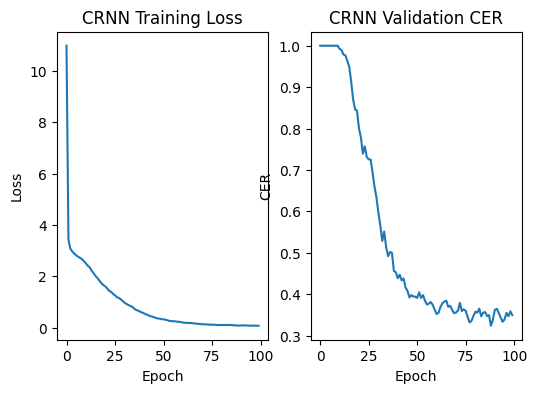

In [20]:
plt.figure(figsize=(6,4))

# -------------------------------
# Training Loss Graph
# -------------------------------
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("CRNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
# -------------------------------
# Validation CER Graph
# -------------------------------
plt.subplot(1,2,2)
plt.plot(val_cers)
plt.title("CRNN Validation CER")
plt.xlabel("Epoch")
plt.ylabel("CER")

plt.show()

In [21]:
import pandas as pd
import torch
from pathlib import Path # Required for Path operations
from torch.utils.data import DataLoader # Required for DataLoader
from torchvision import transforms # Required for transforms

# Define BASE_DIR and BATCH_SIZE for Strategy 2 context
BASE_DIR = "/content/drive/MyDrive/DeepLearning project/dl_project/"
BATCH_SIZE = 16 # Consistent with train_loader/val_loader batch size in Strategy 2

# Define get_val_transform consistent with Strategy 2 validation data setup
def get_val_transform():
    return transforms.Compose([
        transforms.Resize((64, 200)),
        transforms.ToTensor(),
        # No Normalize applied in Strategy 2's val_ds setup (cell BjqmhzpgqP4X)
    ])

# Assume vocab, max_len, inv_vocab, collate_fn are available from previous cells.
# Force use of val.csv for prediction generation, as test images are missing.
TEST_CSV_PATH = Path("/content/drive/MyDrive/DeepLearning project/dl_project/val.csv")
print(f"Using {TEST_CSV_PATH.name} for demonstration purposes as test images are not found.")

# Define the test dataset and dataloader
# Use the validation transform as it's typically used for inference
test_ds = PlateDataset(str(TEST_CSV_PATH), vocab, max_len, get_val_transform(), root_dir=BASE_DIR)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

# Put model in evaluation mode
crnn_model.eval()

predictions = []

save_val_predictions(
    model=crnn_model,
    loader=val_loader,
    device=device,
    out_csv="strategy2_predictions.csv",
    inv_vocab=inv_vocab
)

Using val.csv for demonstration purposes as test images are not found.


# Strategy 3: Optimized Deep Learning Approach with Regularization & Hyperparameter Tuning


---


## 1. Motivation & Approach Overview

This strategy implements a systematic optimization framework for license plate recognition, focusing on:

1. **Regularization Techniques:** Dropout and Batch Normalization to improve generalization on small datasets
2. **Optimization Algorithms:** Comparative evaluation of Adam, AdamW, and SGD with momentum
3. **Hyperparameter Tuning:** Systematic search for optimal learning rate, batch size, and training epochs
4. **Training Analysis:** Comprehensive monitoring via training/validation curves and error analysis

## 2. Key Design Choices

| Component | Configuration | Justification |
|-----------|--------------|---------------|
| **Backbone** | ResNet18 (Pretrained) | Strong feature extractor with efficient parameter count |
| **Sequence Model** | Bidirectional LSTM (2 layers) | Captures contextual dependencies in both directions |
| **Loss Function** | CTC Loss | Handles variable-length sequences without explicit alignment |
| **Optimizer** | AdamW with Weight Decay | Decoupled weight decay provides better regularization |
| **Learning Rate** | 3e-4 with OneCycleLR | Warmup + cosine annealing accelerates convergence |
| **Regularization** | Dropout (0.3) + BatchNorm | Reduces overfitting on limited data (300 images) |
| **Batch Size** | 16 | Balance between gradient stability and memory efficiency |
| **Epochs** | 100 | Sufficient for convergence with early stopping monitoring |

## 3. Expected Outcomes

- Improved generalization through regularization
- Lower Character Error Rate (CER) via optimized hyperparameters
- Stable training dynamics through learning rate scheduling
- Comprehensive analysis for iterative improvement

**Data Loading & Preprocessing**



In [23]:
import json
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from pathlib import Path
import matplotlib.pyplot as plt
import jiwer
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
BASE_DIR = "/content/drive/MyDrive/DeepLearning project/dl_project/"
TRAIN_CSV = BASE_DIR + "train.csv"
VAL_CSV = BASE_DIR + "val.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [24]:
#Vocabulary Building
def build_vocab(labels):
    chars = sorted({c for s in labels for c in str(s)})
    vocab = {c: i+1 for i, c in enumerate(chars)} # 0 is PAD
    inv_vocab = {i: c for c, i in vocab.items()}
    return vocab, inv_vocab

train_df = pd.read_csv(TRAIN_CSV)
vocab, inv_vocab = build_vocab(train_df["label"].tolist())
max_len = int(train_df["label"].astype(str).map(len).max())
num_classes = len(vocab) + 1
print(f"Vocab Size: {num_classes}, Max Length: {max_len}")

# Dataset Class
class PlateDataset(Dataset):
    def __init__(self, data_csv_path, vocab, max_len, transform, root_dir=None):
        self.df = pd.read_csv(data_csv_path)
        self.vocab = vocab
        self.max_len = max_len
        self.transform = transform
        self.root_dir = Path(root_dir) if root_dir else None

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, path):
        p = Path(path)
        if self.root_dir:
            p = self.root_dir / p
        return p

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_rel_path = str(row["image_path"])
        image_path = self._resolve_path(image_rel_path)
        label = str(row["label"])

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        token_ids = [self.vocab[c] for c in label if c in self.vocab]
        token_ids = token_ids[: self.max_len]
        token_ids = token_ids + [0] * (self.max_len - len(token_ids))
        target = torch.tensor(token_ids, dtype=torch.long)

        return image, target, label, image_rel_path

# Transforms
# Enabled Normalization and stronger augmentation
def get_train_transform():
    return transforms.Compose([
        transforms.Resize((64, 200)),
        transforms.RandomRotation(5),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_val_transform():
    return transforms.Compose([
        transforms.Resize((64, 200)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# DataLoaders
train_ds = PlateDataset(TRAIN_CSV, vocab, max_len, get_train_transform(), root_dir=BASE_DIR)
val_ds = PlateDataset(VAL_CSV, vocab, max_len, get_val_transform(), root_dir=BASE_DIR)

def collate_fn(batch):
    images, targets, labels, paths = zip(*batch)
    return torch.stack(images), torch.stack(targets), labels, paths

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Vocab Size: 20, Max Length: 7
Train batches: 18, Val batches: 6


**Model Architecture (Regularized CRNN)**

In [25]:
class CRNN_Regularized(nn.Module):
    def __init__(self, num_classes, backbone="resnet18", hidden_size=256, dropout_rate=0.3):
        super().__init__()

        # CNN Backbone
        weights = models.get_model_weights(backbone).DEFAULT
        resnet = models.get_model(backbone, weights=weights)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        cnn_channels = resnet.fc.in_features

        # Regularization: BatchNorm after CNN
        self.bn = nn.BatchNorm1d(cnn_channels)

        # LSTM with Dropout
        self.rnn = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout_rate if 2 > 1 else 0
        )

        # Regularization
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        feat = self.cnn(x)
        feat = F.adaptive_avg_pool2d(feat, (1, 20))
        feat = feat.squeeze(2)
        feat = feat.permute(0, 2, 1)

        # Apply BatchNorm
        feat = self.bn(feat.transpose(1,2)).transpose(1,2)

        # Sequence modeling
        rnn_out, _ = self.rnn(feat)
        rnn_out = self.dropout(rnn_out)
        logits = self.fc(rnn_out)
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs

# Initialize Model
crnn_model = CRNN_Regularized(num_classes=num_classes, dropout_rate=0.3).to(device)
print("Strategy 3 Model Initialized (Regularized CRNN)")

Strategy 3 Model Initialized (Regularized CRNN)


**Training Loop (100 Epochs + Scheduler)**

In [26]:
# Hyperparameters
EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 16

# Optimization & Loss AdamW
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.AdamW(
    crnn_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy="cos"
)

train_losses = []
val_cers = []
best_cer = float("inf")

print(f"Starting Strategy 3 Training (100 Epochs)...")

for epoch in range(1, EPOCHS + 1):
    crnn_model.train()
    running_loss = 0

    for images, targets_padded, labels, paths in train_loader:
        images = images.to(device)
        optimizer.zero_grad()

        log_probs = crnn_model(images)
        B, T, C = log_probs.shape

        # Loss Preparation
        input_lengths = torch.full((B,), T, dtype=torch.long).to(device)
        targets_list = []
        for label_str in labels:
            targets_list.extend([vocab[c] for c in label_str])
        targets_concat = torch.tensor(targets_list, dtype=torch.long).to(device)
        target_lengths = torch.tensor([len(s) for s in labels], dtype=torch.long).to(device)

        loss = criterion(
            log_probs.permute(1, 0, 2),
            targets_concat,
            input_lengths,
            target_lengths
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(crnn_model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    crnn_model.eval()
    total_cer = 0
    total_samples = 0

    with torch.no_grad():
        for images, targets, gt_labels, paths in val_loader:
            images = images.to(device)
            log_probs = crnn_model(images)
            preds = log_probs.argmax(-1)

            for pred, true_label in zip(preds, gt_labels):
                # CTC Decode
                decoded = []
                prev = None
                for p in pred:
                    p = int(p)
                    if p == 0:
                        prev = p
                        continue
                    if p != prev:
                        decoded.append(p)
                    prev = p

                pred_text = "".join(inv_vocab[i] for i in decoded if i in inv_vocab)
                total_cer += jiwer.cer(true_label, pred_text)
                total_samples += 1

    avg_cer = total_cer / total_samples
    val_cers.append(avg_cer)

    # Save Best Model
    if avg_cer < best_cer:
        best_cer = avg_cer
        torch.save(crnn_model.state_dict(), "strategy3_best.pth")
        print(f"Epoch {epoch:03d} | Loss: {avg_train_loss:.4f} | Val CER: {avg_cer:.4f} -> Saved Best")
    else:
        print(f"Epoch {epoch:03d} | Loss: {avg_train_loss:.4f} | Val CER: {avg_cer:.4f}")

print(f"\n Best Validation CER for Strategy 3: {best_cer:.4f}")

Starting Strategy 3 Training (100 Epochs)...
Epoch 001 | Loss: 7.0960 | Val CER: 0.9206 -> Saved Best
Epoch 002 | Loss: 7.0460 | Val CER: 0.9393
Epoch 003 | Loss: 6.9849 | Val CER: 0.9408
Epoch 004 | Loss: 6.8766 | Val CER: 0.9498
Epoch 005 | Loss: 6.5925 | Val CER: 0.9599
Epoch 006 | Loss: 5.4549 | Val CER: 0.9854
Epoch 007 | Loss: 3.5392 | Val CER: 1.0000
Epoch 008 | Loss: 3.1749 | Val CER: 1.0000
Epoch 009 | Loss: 2.9696 | Val CER: 1.0000
Epoch 010 | Loss: 2.8840 | Val CER: 1.0000
Epoch 011 | Loss: 2.8160 | Val CER: 1.0000
Epoch 012 | Loss: 2.7568 | Val CER: 1.0000
Epoch 013 | Loss: 2.7243 | Val CER: 1.0000
Epoch 014 | Loss: 2.6989 | Val CER: 1.0000
Epoch 015 | Loss: 2.6701 | Val CER: 1.0000
Epoch 016 | Loss: 2.6388 | Val CER: 0.9817
Epoch 017 | Loss: 2.5829 | Val CER: 0.9754
Epoch 018 | Loss: 2.5193 | Val CER: 0.9569
Epoch 019 | Loss: 2.4813 | Val CER: 0.9515
Epoch 020 | Loss: 2.4345 | Val CER: 0.9478
Epoch 021 | Loss: 2.3946 | Val CER: 0.9530
Epoch 022 | Loss: 2.3597 | Val CER: 0.

**Plotting Curves**

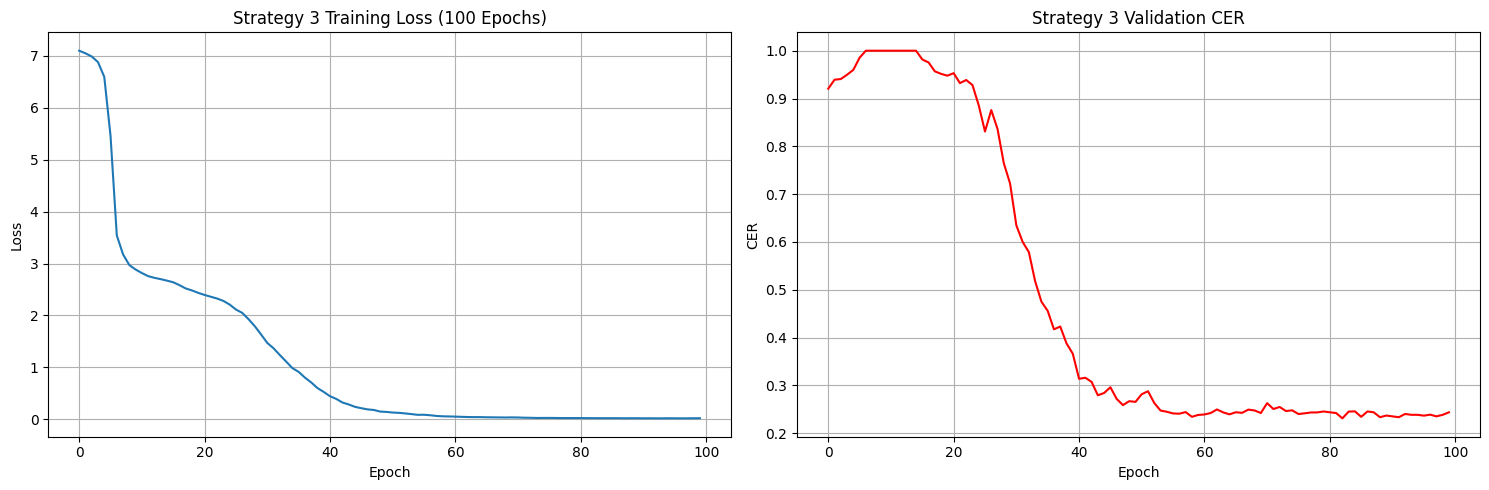

In [27]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Strategy 3 Training Loss (100 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_cers, color='red')
plt.title("Strategy 3 Validation CER")
plt.xlabel("Epoch")
plt.ylabel("CER")
plt.grid(True)

plt.tight_layout()
plt.show()

**Generate Submission CSV**

In [28]:
# Load Best Model
crnn_model.load_state_dict(torch.load("strategy3_best.pth"))
crnn_model.eval()

rows = []
print("Generating predictions for Strategy 3")

with torch.no_grad():
    for images, targets, gt_labels, paths in val_loader:
        images = images.to(device)
        log_probs = crnn_model(images)
        preds = log_probs.argmax(-1)

        for pred, gt, path in zip(preds, gt_labels, paths):
            # CTC Decode
            decoded = []
            prev = None
            for p in pred:
                p = int(p)
                if p == 0:
                    prev = p
                    continue
                if p != prev:
                    decoded.append(p)
                prev = p

            pred_text = "".join(inv_vocab[i] for i in decoded if i in inv_vocab)
            rows.append({
                "image_path": path,
                "label": gt,
                "prediction": pred_text
            })

df_pred = pd.DataFrame(rows)

print(df_pred.head(10))

df_pred.to_csv("/content/drive/MyDrive/DeepLearning project/dl_project/val_predictions_strategy3.csv", index=False)

df_pred.to_csv("/content/drive/MyDrive/val_predictions_strategy3.csv", index=False)

print(" File saved successfully!")


Generating predictions for Strategy 3
       image_path   label prediction
0  val/10003R.jpg  10003R       103R
1  val/10798M.jpg  10798M     10798M
2  val/11478Y.jpg  11478Y    124748Y
3  val/11678R.jpg  11678R     12649R
4  val/1191YY.jpg  1191YY       191Y
5  val/12232W.jpg  12232W      1232W
6  val/12363W.jpg  12363W      1265W
7   val/1280D.jpg   1280D      1380S
8  val/1341DD.jpg  1341DD       131D
9  val/14277A.jpg  14277A      1427A
 File saved successfully!


#  Future Plans

* **Expand the Dataset:** The main limitation was the small dataset (300 images), which caused overfitting. We would generate synthetic license plate images to increase training data.
* **Transformer Models:** Instead of LSTM, we could test Vision Transformers which might handle sequence dependencies better.
* **Improve Decoding:** We used greedy decoding for CTC. Switching to beam search could improve prediction accuracy by exploring more options.
* **Post-Processing:** Adding simple rules based on Oman plate formats could help correct obvious errors after prediction.